# 04. Simple Linear Regression: Theory and Workflow

This chapter introduces the simple linear regression model and fits one example from start to finish.

The statistical model is:

$$
Y_i = \beta_0 + \beta_1 x_i + \epsilon_i
$$

For this data set:

- response $Y$: `Fuelcons`
- predictor $x$: `Temp`
- question: how does expected fuel consumption change as temperature changes?

## What regression is doing

Regression predicts or explains a response variable using one or more predictor variables. If we ignored predictors, a rough prediction for a response would be the sample mean. Regression improves on that idea by letting the prediction change with information in $x$.

For simple linear regression, each observation is modeled as:

$$
y_i = \beta_0 + \beta_1 x_i + \epsilon_i.
$$

Here:

- $\beta_0$ is the intercept,
- $\beta_1$ is the slope,
- $\epsilon_i$ is the random error for observation $i$,
- $\hat y_i = b_0 + b_1x_i$ is the fitted value from the data.

The slope is the main object of interpretation. It is the estimated change in the mean response for a one-unit increase in the predictor.

## Why "linear" regression can include curves

"Linear" means linear in the unknown coefficients, not necessarily a perfectly straight plot in the original variable. For example, these are linear regression models:

$$
y = \beta_0 + \beta_1x + \epsilon
$$

and

$$
y = \beta_0 + \beta_1x^2 + \epsilon.
$$

The second model uses $x^2$ as a predictor, but the coefficients still enter linearly. A model such as $y = \beta_0 + e^{\beta_1x} + \epsilon$ is not linear in the same sense.

## Least squares

The fitted line is chosen by minimizing the sum of squared residuals:

$$
SSE = \sum_{i=1}^{n}(y_i-\hat y_i)^2.
$$

The least-squares estimators are:

$$
b_1 = \frac{\sum_{i=1}^{n}(x_i-\bar x)(y_i-\bar y)}{\sum_{i=1}^{n}(x_i-\bar x)^2}
$$

and

$$
b_0 = \bar y - b_1\bar x.
$$

These formulas are useful because they show the role of co-movement between $x$ and $y$. If large $x$ values tend to occur with small $y$ values, the numerator is negative and the slope is negative.

For ordinary least squares with an intercept:

- the residuals sum to zero,
- the fitted line passes through $(\bar x,\bar y)$,
- the fitted line has the smallest SSE among all straight lines.

## Load and plot the data

## Browser package setup

Run the next cell before the first analysis cell. It loads the scientific Python packages used in this module into the browser-based Python kernel.

The first run in a browser session can take a little time. Later notebooks usually load faster because the browser can reuse cached packages.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()


Using the current Python environment.


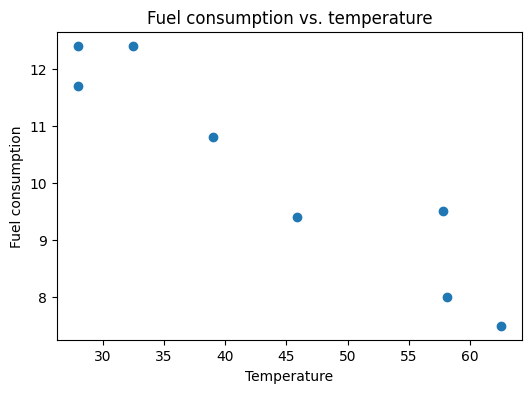

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

from checks import check_close, check_sign, model_snapshot

fuel = pd.read_csv("data/fuelcons.csv")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fuel["Temp"], fuel["Fuelcons"])
ax.set_xlabel("Temperature")
ax.set_ylabel("Fuel consumption")
ax.set_title("Fuel consumption vs. temperature")
plt.show()

## Compute the least-squares estimates

Software fits the line by carrying out the least-squares formulas from the previous section. Seeing the arithmetic once makes the software output easier to read.

For this data set, let $x$ be `Temp` and $y$ be `Fuelcons`. Compute

$$
S_{xx}=\sum_i(x_i-\bar{x})^2, \qquad S_{xy}=\sum_i(x_i-\bar{x})(y_i-\bar{y}),
$$

then

$$
b_1=\frac{S_{xy}}{S_{xx}}, \qquad b_0=\bar{y}-b_1\bar{x}.
$$

This gives the same fitted line that regression software will report.


In [3]:
x = fuel["Temp"]
y = fuel["Fuelcons"]

xbar = x.mean()
ybar = y.mean()
Sxx = ((x - xbar) ** 2).sum()
Sxy = ((x - xbar) * (y - ybar)).sum()

b1_formula = Sxy / Sxx
b0_formula = ybar - b1_formula * xbar

print(f"xbar = {xbar:.3f}")
print(f"ybar = {ybar:.3f}")
print(f"Sxx = {Sxx:.3f}")
print(f"Sxy = {Sxy:.3f}")
print(f"fitted line by formula: y_hat = {b0_formula:.3f} + ({b1_formula:.3f}) x")


xbar = 43.975
ybar = 10.213
Sxx = 1404.355
Sxy = -179.647
fitted line by formula: y_hat = 15.838 + (-0.128) x


## Fit the model with software

The course notebooks mostly use the `statsmodels` formula API because it is readable:

```text
response ~ predictor
```

The formula `Fuelcons ~ Temp` means "fit fuel consumption as a linear function of temperature." After fitting, `model.summary()` gives coefficient estimates, standard errors, test statistics, p-values, and model-fit summaries.


In [4]:
model = ols("Fuelcons ~ Temp", data=fuel).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Fuelcons   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     53.69
Date:                Mon, 18 May 2026   Prob (F-statistic):           0.000330
Time:                        01:53:14   Log-Likelihood:                -6.8061
No. Observations:                   8   AIC:                             17.61
Df Residuals:                       6   BIC:                             17.77
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.8379      0.802     19.754      0.0

## The same fit with the matrix API

Some examples and homework scaffolds use the matrix-style `statsmodels.api` interface. In that style, you manually add an intercept column with `sm.add_constant()` and fit with `sm.OLS(y, X).fit()`.

Both interfaces are ordinary least squares. The coefficient names look different, but the numerical fitted line is the same.


In [5]:
import statsmodels.api as sm

X = sm.add_constant(fuel["Temp"])
model_matrix_api = sm.OLS(fuel["Fuelcons"], X).fit()

print(model_matrix_api.params)
print()
print("Formula API coefficients:")
print(model.params)


const    15.837857
Temp     -0.127922
dtype: float64

Formula API coefficients:
Intercept    15.837857
Temp         -0.127922
dtype: float64


## Extract the quantities we need

The full summary is useful, but in practice you should learn to pull out specific quantities.

In [6]:
snapshot = model_snapshot(model)
snapshot

{'intercept': 15.837857414969859,
 'slope': -0.12792171495099167,
 'r_squared': 0.8994888707532966,
 'slope_p_value': 0.00033005230221731053,
 'rmse': 0.5665613066277241}

In [7]:
intercept = snapshot["intercept"]
slope = snapshot["slope"]
r_squared = snapshot["r_squared"]
slope_p_value = snapshot["slope_p_value"]
rmse = snapshot["rmse"]

print(f"Intercept: {intercept:.3f}")
print(f"Slope: {slope:.3f}")
print(f"R-squared: {r_squared:.3f}")
print(f"Slope p-value: {slope_p_value:.4f}")
print(f"RMSE: {rmse:.3f}")

Intercept: 15.838
Slope: -0.128
R-squared: 0.899
Slope p-value: 0.0003
RMSE: 0.567


## Checkpoint 1: slope

The fitted slope should be negative. In this example, each one-unit increase in temperature is associated with a decrease of about 0.128 units in expected fuel consumption.

In [8]:
student_slope = slope

print(check_sign("slope", student_slope, "negative"))
print(check_close(
    "slope",
    student_slope,
    expected=-0.1279,
    tolerance=0.005,
    hint="Use model.params['Temp']."
))

PASS: slope has the expected negative sign.
PASS: slope is close enough: -0.1279.


## Plot the fitted line

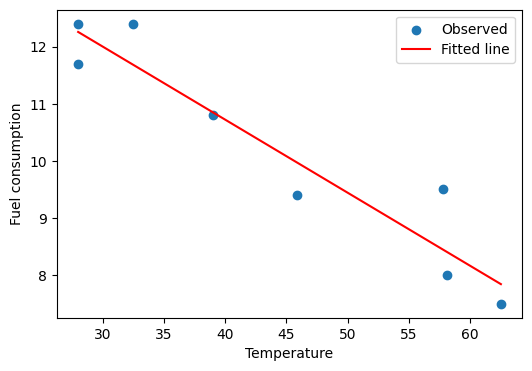

In [9]:
fuel_with_fit = fuel.copy()
fuel_with_fit["fitted"] = model.fittedvalues

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fuel_with_fit["Temp"], fuel_with_fit["Fuelcons"], label="Observed")
ax.plot(
    fuel_with_fit["Temp"],
    fuel_with_fit["fitted"],
    color="red",
    label="Fitted line",
)
ax.set_xlabel("Temperature")
ax.set_ylabel("Fuel consumption")
ax.legend()
plt.show()

## Interpret the fitted equation

The fitted equation is:

$$
\widehat{Fuelcons} = 15.838 - 0.128 Temp
$$

Interpretation:

- Intercept: when `Temp = 0`, the fitted mean fuel consumption is 15.838. This may be outside the useful range of the data, so interpret it carefully.
- Slope: for each one-unit increase in `Temp`, the fitted mean fuel consumption decreases by about 0.128 units.
- R-squared: about 90% of the variation in fuel consumption is explained by a straight-line relationship with temperature in this small data set.

The fitted line passes through the sample center. We can verify that quickly.

## Should we remove the intercept?

The lecture notes discuss **regression through the origin**, where the model is forced to be

$$
Y_i = \beta_1 x_i + \epsilon_i.
$$

This should be a deliberate modeling choice, not an automatic reaction to an intercept p-value. Removing the intercept forces the fitted line through $(0,0)$ and changes the least-squares estimates, fitted values, residuals, MSE, and intervals.

Keep the intercept by default unless the problem context gives a strong reason that the mean response must be exactly zero when $x=0$ and the linear relationship remains reasonable near the origin. In many forecasting problems, $x=0$ is outside the observed range or not meaningful, so the intercept is mainly a mathematical anchor for the fitted line.


In [10]:
x_bar = fuel["Temp"].mean()
y_bar = fuel["Fuelcons"].mean()
fitted_at_x_bar = intercept + slope * x_bar

print(f"x-bar = {x_bar:.3f}")
print(f"y-bar = {y_bar:.3f}")
print(f"fitted value at x-bar = {fitted_at_x_bar:.3f}")
print(check_close("fitted value at x-bar", fitted_at_x_bar, expected=y_bar, tolerance=1e-10))

x-bar = 43.975
y-bar = 10.213
fitted value at x-bar = 10.213
PASS: fitted value at x-bar is close enough: 10.21.


## Checkpoint 2: predicted mean at Temp = 40

Use the fitted equation to compute the predicted mean fuel consumption when `Temp = 40`.

In [11]:
temp_value = 40
predicted_mean_40 = intercept + slope * temp_value
predicted_mean_40

10.720988816930191

In [12]:
print(check_close(
    "predicted mean at Temp = 40",
    predicted_mean_40,
    expected=10.721,
    tolerance=0.02,
    hint="Use intercept + slope * 40."
))

PASS: predicted mean at Temp = 40 is close enough: 10.72.


## From output to conclusion

A good model conclusion is not just a number. It should mention the variables, direction, approximate magnitude, and uncertainty or limitations.

```{admonition} Reference conclusion
:class: dropdown

In this sample, fuel consumption decreases as temperature increases. The fitted model estimates a slope of about -0.128, meaning that each one-unit increase in temperature is associated with about 0.128 fewer units of expected fuel consumption. The relationship is strong in this small data set, with R-squared about 0.90, but the conclusion should be checked with residual diagnostics before using the model for decisions.
```

## What to reuse

For a new simple regression problem, change only three things:

1. the data file,
2. the response column,
3. the predictor column.

The workflow stays the same: plot, fit, extract, interpret, diagnose.